In [1]:
sessionInfo()

R version 4.5.3 (2026-03-11)
Platform: x86_64-pc-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3 
LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/libopenblasp-r0.3.20.so;  LAPACK version 3.10.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

loaded via a namespace (and not attached):
 [1] digest_0.6.39     IRdisplay_1.1     base64enc_0.1-6   fastmap_1.2.0    
 [5] glue_1.8.0        htmltools_0.5.9   repr_1.1.7        lifecycle_1.0.5  
 [9] cl

In [4]:
install.packages("caret")
install.packages("rpart")
install.packages("rpart.plot")
install.packages("randomForest")
install.packages("pROC")
# install.packages("gains") # Package 'gains' is not available for this R version
install.packages("ggplot2")
install.packages("tidyr")
install.packages("dplyr")
install.packages("MASS")
library(caret)
library(rpart)
library(rpart.plot)
library(randomForest)
library(pROC)
# library(gains) # Package 'gains' is not available for this R version
library(ggplot2)
library(tidyr)
library(dplyr)
library(MASS)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘dplyr’


The following object is masked from ‘package:randomForest’:

    combine


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setd

The default cutoff of 0.5 assumes that a false negative costs the same as a false positive. In the
German Credit dataset the cost matrix is:

| Decision | Reality | Payoff |
|---|---|---|
| Approve | Good credit | +100 DM |
| Approve | Bad credit  | −500 DM |
| Reject  | Either      |    0 DM |

A bad loan costs 5× more than a missed good loan. The optimal cutoff
should therefore sit higher than 0.5

In [6]:
# Read data

german.df          <- read.csv("GermanCredit.csv")
german.df$OBS.     <- NULL
german.df$RESPONSE <- as.factor(german.df$RESPONSE)

set.seed(1)
train.rows <- sample(rownames(german.df), nrow(german.df) * 0.6)
valid.rows <- setdiff(rownames(german.df), train.rows)
train.df   <- german.df[train.rows, ]
valid.df   <- german.df[valid.rows, ]

# Fit logistic regression (same as case study Task 2)
logit.reg      <- glm(RESPONSE ~ ., data = train.df, family = "binomial")
logit.pred.prob <- predict(logit.reg, valid.df, type = "response")

true_y <- valid.df$RESPONSE

In [15]:
calc_profit <- function(probs, true_labels, cutoff,
                        gain_good = 100, cost_bad = -500) {
  pred  <- ifelse(probs >= cutoff, 1, 0)
  true  <- as.integer(as.character(true_labels))
  profit <- ifelse(pred == 1 & true == 1,  gain_good,
            ifelse(pred == 1 & true == 0,  cost_bad, 0))
  sum(profit)
}


cutoffs <- seq(0.01, 0.99, by = 0.01)

sweep_df <- data.frame(
  Cutoff      = cutoffs,
  Profit      = sapply(cutoffs, function(c)
                  calc_profit(logit.pred.prob, true_y, c)),
  Approvals   = sapply(cutoffs, function(c)
                  sum(logit.pred.prob >= c)),
  Sensitivity = sapply(cutoffs, function(c) {
                  pred <- factor(ifelse(logit.pred.prob >= c, 1, 0), levels = levels(true_y))
                  cm   <- confusionMatrix(pred, true_y, positive = "1")
                  cm$byClass["Sensitivity"]
                }),
  Specificity = sapply(cutoffs, function(c) {
                  pred <- factor(ifelse(logit.pred.prob >= c, 1, 0), levels = levels(true_y))
                  cm   <- confusionMatrix(pred, true_y, positive = "1")
                  cm$byClass["Specificity"]
                })
)

optimal_row    <- sweep_df[which.max(sweep_df$Profit), ]
optimal_cutoff <- optimal_row$Cutoff
optimal_profit <- optimal_row$Profit

# Calculate profit at default cutoff (0.5)
default_profit <- calc_profit(logit.pred.prob, true_y, 0.5)

cat("Optimal cutoff   :", optimal_cutoff, "\n")
cat("Profit at optimal:", optimal_profit, "DM\n")
cat("Profit at default:", default_profit,  "DM\n")
cat("Profit improvement:", optimal_profit - default_profit, "DM\n")

Optimal cutoff   : 0.84 
Profit at optimal: 10800 DM
Profit at default: -4500 DM
Profit improvement: 15300 DM


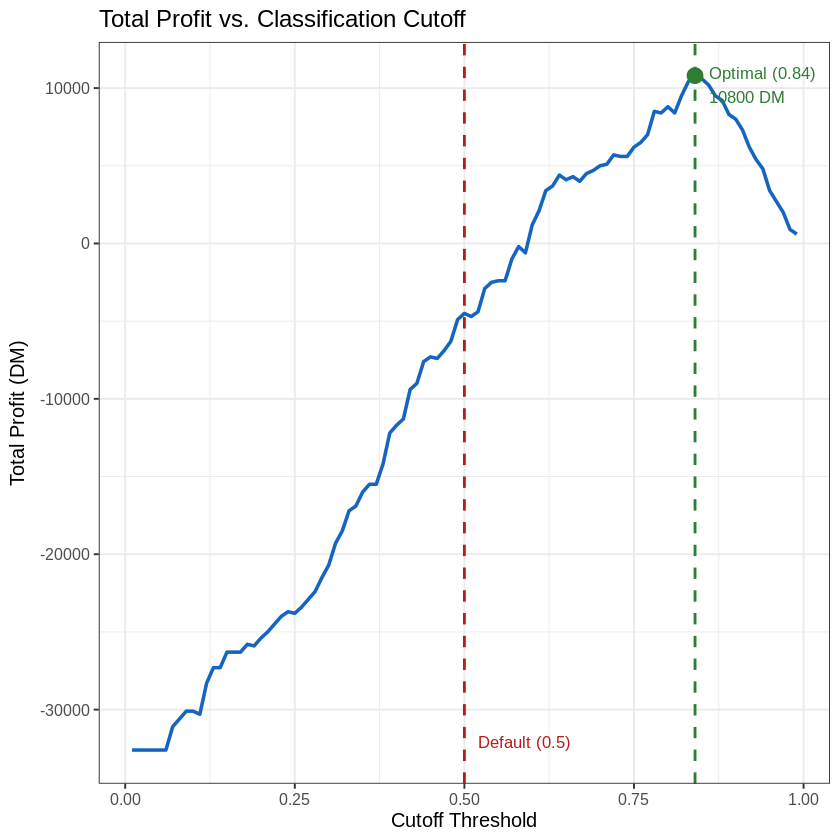

In [22]:
# Plotting the tradeoffs

ggplot(sweep_df, aes(x = Cutoff, y = Profit)) +
  geom_line(color = "#1565C0", linewidth = 1) +
  geom_vline(xintercept = 0.5,            linetype = "dashed",
             color = "#B71C1C", linewidth = 0.8) +
  geom_vline(xintercept = optimal_cutoff, linetype = "dashed",
             color = "#2E7D32", linewidth = 0.8) +
  geom_point(data = optimal_row, aes(x = Cutoff, y = Profit),
             color = "#2E7D32", size = 4) +
  annotate("text", x = 0.5 + 0.02, y = min(sweep_df$Profit) + 500,
           label = "Default (0.5)", color = "#B71C1C", hjust = 0, size = 3.5) +
  annotate("text", x = optimal_cutoff + 0.02,
           y = optimal_profit - 600,
           label = paste0("Optimal (", optimal_cutoff, ")\n",
                          optimal_profit, " DM"),
           color = "#2E7D32", hjust = 0, size = 3.5) +
  labs(title    = "Total Profit vs. Classification Cutoff",
       x = "Cutoff Threshold", y = "Total Profit (DM)") +
  theme_bw(base_size = 12)

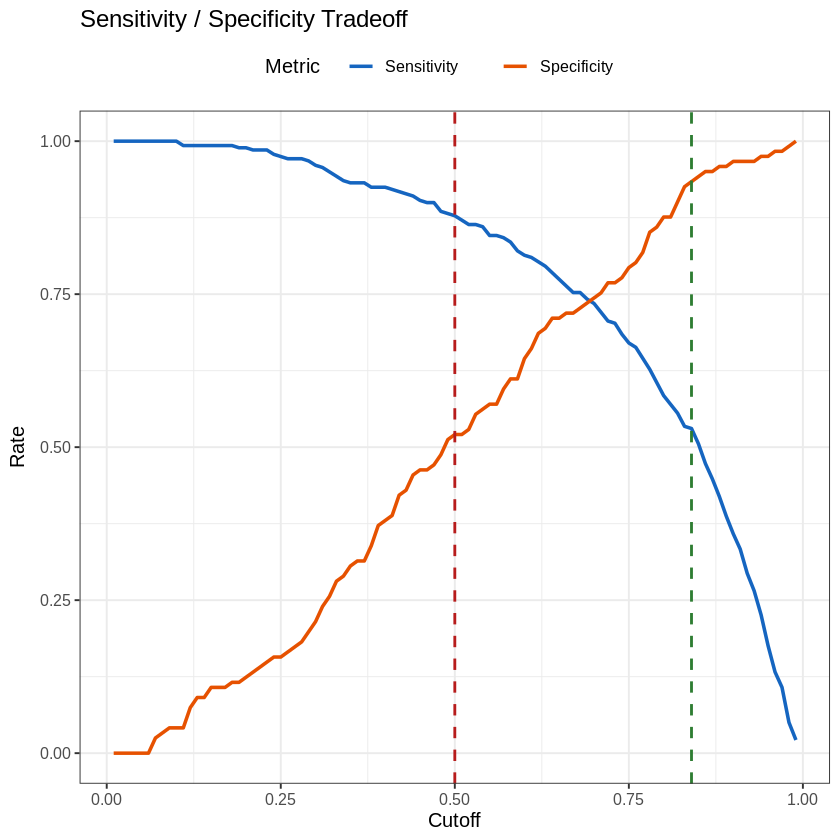

In [29]:
tradeoff_df <- sweep_df %>%
  dplyr::select(Cutoff, Sensitivity, Specificity) %>%
  pivot_longer(cols = c(Sensitivity, Specificity),
               names_to = "Metric", values_to = "Value")

ggplot(tradeoff_df, aes(x = Cutoff, y = Value, color = Metric)) +
  geom_line(linewidth = 1) +
  geom_vline(xintercept = optimal_cutoff, linetype = "dashed",
             color = "#2E7D32", linewidth = 0.8) +
  geom_vline(xintercept = 0.5, linetype = "dashed",
             color = "#B71C1C", linewidth = 0.8) +
  scale_color_manual(values = c("Sensitivity" = "#1565C0",
                                 "Specificity" = "#E65100")) +
  labs(title    = "Sensitivity / Specificity Tradeoff",
       x = "Cutoff", y = "Rate") +
  theme_bw(base_size = 12) +
  theme(legend.position = "top")

In [37]:
pred_default <- as.factor(ifelse(logit.pred.prob >= 0.5,            1, 0))
pred_optimal <- as.factor(ifelse(logit.pred.prob >= optimal_cutoff, 1, 0))

cat("Confusion Matrix at 0.5\n")
cm_default <- confusionMatrix(pred_default, true_y, positive = "1")
print(cm_default$table)
cat("Accuracy:", round(cm_default$overall["Accuracy"], 4), "\n")
cat("Sensitivity :", #catching good loans
    round(cm_default$byClass["Sensitivity"], 4), "\n")
cat("Specificity : ", #catching bad loans
    round(cm_default$byClass["Specificity"], 4), "\n")
cat("Net profit:", default_profit, "DM\n\n")

cat(" Confusion Matrix at ",optimal_cutoff, " \n")
cm_optimal <- confusionMatrix(pred_optimal, true_y, positive = "1")
print(cm_optimal$table)
cat("Accuracy:", round(cm_optimal$overall["Accuracy"], 4), "\n")
cat("Sensitivity:", round(cm_optimal$byClass["Sensitivity"], 4), "\n")
cat("Specificity:", round(cm_optimal$byClass["Specificity"], 4), "\n")
cat("Net profit:", optimal_profit, "DM\n")

Confusion Matrix at 0.5
          Reference
Prediction   0   1
         0  63  34
         1  58 245
Accuracy: 0.77 
Sensitivity : 0.8781 
Specificity :  0.5207 
Net profit: -4500 DM

 Confusion Matrix at  0.84  
          Reference
Prediction   0   1
         0 113 131
         1   8 148
Accuracy: 0.6525 
Sensitivity: 0.5305 
Specificity: 0.9339 
Net profit: 10800 DM


In [44]:
tree.mod       <- rpart(RESPONSE ~ ., data = train.df, method = "class")
tree.prob      <- predict(tree.mod, valid.df, type = "prob")[, "1"]

tree_cutoffs   <- seq(0.01, 0.99, by = 0.01)
tree_profits   <- sapply(tree_cutoffs, function(c)
                    calc_profit(tree.prob, true_y, c))
tree_opt_cut   <- tree_cutoffs[which.max(tree_profits)]
tree_opt_profit <- max(tree_profits)

pre            <- preProcess(train.df[, -which(names(train.df) == "RESPONSE")],
                             method = c("range"))
train.sc       <- predict(pre, train.df)
valid.sc       <- predict(pre, valid.df)

set.seed(1)
nn.mod         <- train(RESPONSE ~ ., data = train.sc, method = "nnet",
                        tuneGrid  = data.frame(size = 5, decay = 0.1),
                        trControl = trainControl(method = "none"),
                        trace = FALSE, maxit = 500)
nn.prob        <- predict(nn.mod, valid.sc, type = "prob")[, "1"]

nn_profits     <- sapply(tree_cutoffs, function(c)
                    calc_profit(nn.prob, true_y, c))
nn_opt_cut     <- tree_cutoffs[which.max(nn_profits)]
nn_opt_profit  <- max(nn_profits)

summary_tbl <- data.frame(
  Model            = c("Logistic Regression", "Classification Tree", "Neural Network"),
  Default_Profit   = c(
    calc_profit(logit.pred.prob, true_y, 0.5),
    calc_profit(tree.prob,       true_y, 0.5),
    calc_profit(nn.prob,         true_y, 0.5)
  ),
  Optimal_Cutoff   = c(optimal_cutoff, tree_opt_cut,    nn_opt_cut),
  Optimal_Profit   = c(optimal_profit, tree_opt_profit, nn_opt_profit)
)
summary_tbl$Improvement <- summary_tbl$Optimal_Profit - summary_tbl$Default_Profit

knitr::kable(summary_tbl, caption = "Profit at Default 0.5 vs. Optimized Cutoff 0.84")





Table: Profit at Default 0.5 vs. Optimized Cutoff 0.84

|Model               | Default_Profit| Optimal_Cutoff| Optimal_Profit| Improvement|
|:-------------------|--------------:|--------------:|--------------:|-----------:|
|Logistic Regression |          -4500|           0.84|          10800|       15300|
|Classification Tree |         -10800|           0.84|           5700|       16500|
|Neural Network      |          -8000|           0.96|           4800|       12800|